In [10]:
import numpy as np

In [11]:
def euclidean_distance(x1, x2):
    return np.sqrt(np.sum((x1-x2)**2))

In [12]:
def get_k_nearest_neighbors(X_train, y_train, test_point, k):
    distances = []
    for i in range(len(X_train)):
        dist = euclidean_distance(X_train[i], test_point)
        distances.append((dist, y_train[i]))
    distances.sort(key=lambda x: x[0])
    return [label for _, label in distances[:k]]

In [13]:
from collections import Counter
def predict_classification(neighbors_labels):
    counter = Counter(neighbors_labels)
    return counter.most_common(1)[0][0]

In [14]:
def knn_predict(X_train, y_train, test_point, k=3):
    neighbors = get_k_nearest_neighbors(X_train, y_train, test_point, k)
    return predict_classification(neighbors)
    

In [20]:
X_train = np.array([[1], [2], [3], [4], [5]])
y_train = np.array([0, 0, 1, 1, 1])
test_point = np.array([3.5])
k =3
print("Predicted Class:", knn_predict(X_train, y_train, test_point, k))

Predicted Class: 1


In [21]:
import pandas as pd

distances = []
for i in range(len(X_train)):
    dist = euclidean_distance(X_train[i], test_point)
    distances.append((X_train[i][0], y_train[i], dist))

# Create DataFrame for table
df = pd.DataFrame(distances, columns=["Training Point", "Label", "Distance"])
df_sorted = df.sort_values("Distance").reset_index(drop=True)
df_sorted["Is_Neighbor"] = ["✅" if i < k else "" for i in range(len(df_sorted))]
print(df_sorted)

   Training Point  Label  Distance Is_Neighbor
0               3      1       0.5           ✅
1               4      1       0.5           ✅
2               2      0       1.5           ✅
3               5      1       1.5            
4               1      0       2.5            


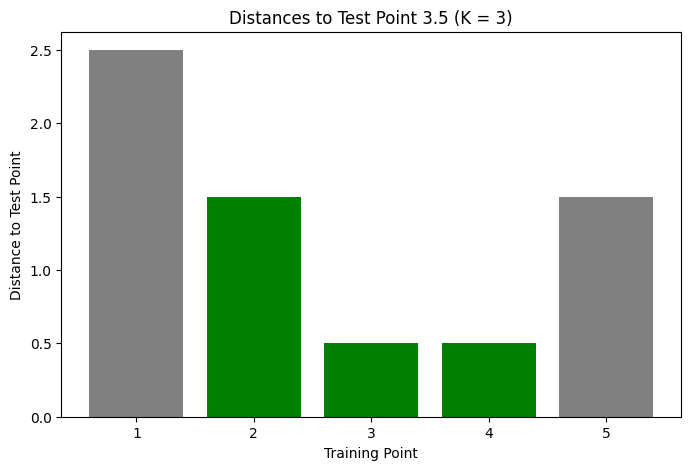

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
colors = ["green" if i < k else "gray" for i in range(len(df_sorted))]
plt.bar(df_sorted["Training Point"], df_sorted["Distance"], color=colors)
plt.xlabel("Training Point")
plt.ylabel("Distance to Test Point")
plt.title(f"Distances to Test Point {test_point[0]} (K = {k})")
plt.show()
